# Credit Risk Data Audit and Feature Engineering


| | |
|---|---|
| **Notebook** | B1_Data_Audit_Feature_Engineering.ipynb |
| **Author** | N L N Sai Krishna Akula |
| **Course** | AAI 500 - Applied Statistics & AI |
| **Dataset** | Credit Risk Modeling Dataset |
| **Date** | June 3, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |


This notebook loads the Phase 1 cleaned credit-risk dataset, audits it, creates feature-engineered columns, and saves the Phase 2 modeling dataset for the next notebook.


In [18]:
# Core data libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PHASE1_DATA_PATH = "../data/processed/phase1/credit_risk_cleaned.csv"
PHASE2_DATA_PATH = "../data/processed/phase2/credit_risk_cleaned.csv"

print("Libraries loaded successfully.")
print("Phase 1 dataset configured:", PHASE1_DATA_PATH)
print("Phase 2 dataset configured:", PHASE2_DATA_PATH)

Libraries loaded successfully.
Phase 1 dataset configured: ../data/processed/phase1/credit_risk_cleaned.csv
Phase 2 dataset configured: ../data/processed/phase2/credit_risk_cleaned.csv


---
### 1.3 Load and Audit the Phase 1 Cleaned Dataset

The modeling workflow starts from the Phase 1 cleaned dataset saved at `data/processed/phase1/credit_risk_cleaned.csv`. The audit is separated into small outputs so each check is easy to explain in a final project presentation.


The first check confirms that the cleaned file loads correctly and shows the dataset size.


In [19]:
df = pd.read_csv(PHASE1_DATA_PATH)

# Print a short load confirmation without exposing any local full file path.
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (29567, 12)


The first five rows provide a quick visual check of the columns and sample values.


In [20]:
# Display sample records to verify the dataset structure before modeling.
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


The preview confirms that borrower details, loan details, and credit history fields are available for modeling. This check helps ensure that later feature engineering uses the expected columns.


In [21]:
# Collect categorical columns and list their levels before encoding.
categorical_cols_initial = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_summary = {
    col: sorted(df[col].dropna().astype(str).unique().tolist())
    for col in categorical_cols_initial
}
pd.DataFrame({
    "column": list(categorical_summary.keys()),
    "levels": [", ".join(vals) for vals in categorical_summary.values()],
})

,column,levels
0,person_home_ownership,"MORTGAGE, OTHER, OWN, RENT"
1,loan_intent,"DEBTCONSOLIDATION, EDUCATION, HOMEIMPROVEMENT,..."
2,loan_grade,"A, B, C, D, E, F, G"
3,cb_person_default_on_file,"N, Y"


Numeric summary statistics show the scale and range of each numeric field before feature engineering.


In [22]:
# Review numeric ranges and distributions before feature engineering.
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
person_age,29567.0,26.726,4.507,20.00,23.00,25.00,29.00,40.00
person_income,29567.0,58588.391,27477.043,4080.00,37863.00,54000.00,75000.00,140004.00
person_emp_length,29567.0,4.629,3.769,0.00,2.00,4.00,7.00,25.00
loan_amnt,29567.0,9278.747,6024.906,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,29567.0,11.000,3.078,5.42,8.49,10.99,13.11,23.22
loan_status,29567.0,0.224,0.417,0.00,0.00,0.00,0.00,1.00
loan_percent_income,29567.0,0.175,0.107,0.01,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,29567.0,5.269,3.315,2.00,3.00,4.00,7.00,17.00


---
## 2. Feature Engineering and Exploratory Analysis

### 2.1 Feature Engineering

This step creates additional columns that make borrower affordability, loan burden, and credit history easier to analyze. The new columns describe income level, loan burden, age group, and past default behavior.

Log transformations reduce the influence of very large financial values. Ratio features compare borrower capacity with requested loan size. Grouped features such as `income_group`, `loan_amount_group`, `loan_percent_income_group`, and `age_group` make default patterns easier to explain.


In [23]:
def add_credit_features(data):
    # Copy the input so the original cleaned dataset is not modified directly.
    out = data.copy()

    # Log transforms reduce the influence of very large income and loan values.
    out["log_person_income"] = np.log1p(out["person_income"])
    out["log_loan_amnt"] = np.log1p(out["loan_amnt"])

    # Ratio features describe affordability and borrower history in relative terms.
    out["income_to_loan_ratio"] = out["person_income"] / out["loan_amnt"].clip(lower=1)
    out["employment_to_age_ratio"] = out["person_emp_length"] / out["person_age"].clip(lower=1)
    out["credit_history_to_age_ratio"] = out["cb_person_cred_hist_length"] / out["person_age"].clip(lower=1)
    out["default_on_file_binary"] = (out["cb_person_default_on_file"] == "Y").astype(int)

    # Numeric grade is useful for analysis while model preprocessing still handles grade encoding.
    grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
    out["loan_grade_numeric"] = out["loan_grade"].map(grade_map)

    # Grouped features make borrower and loan risk patterns easier to explain.
    out["income_group"] = pd.cut(
        out["person_income"],
        bins=[0, 25000, 50000, 75000, 100000, np.inf],
        labels=["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"],
        include_lowest=True,
    )
    out["loan_amount_group"] = pd.cut(
        out["loan_amnt"],
        bins=[0, 5000, 10000, 20000, np.inf],
        labels=["Small", "Medium", "Large", "Very Large"],
        include_lowest=True,
    )
    out["loan_percent_income_group"] = pd.cut(
        out["loan_percent_income"],
        bins=[0, 0.10, 0.20, 0.35, np.inf],
        labels=["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],
        include_lowest=True,
    )
    out["age_group"] = pd.cut(
        out["person_age"],
        bins=[0, 25, 35, np.inf],
        labels=["Young", "Adult", "Experienced Adult"],
        include_lowest=True,
    )
    # Return the feature-engineered dataframe for all later modeling steps.
    return out

In [24]:
df_model = add_credit_features(df)

# Print the new shape after engineered columns are added.
print("Feature-engineered dataset shape:", df_model.shape)

Feature-engineered dataset shape: (29567, 23)


In [25]:
# Preview engineered columns to confirm the feature creation step.
df_model.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_income,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.169623,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,9.169623,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,11.089821,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,10.904138,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,9.200391,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


---
### 2.2 Grouped Feature Default Rate EDA

Grouped features help explain whether risk changes across borrower and loan categories. The outputs below show default rate separately for income group, loan amount group, and loan burden group.


In [26]:
def summarize_default_rate_by_group(data, group_col):
    # Group by the selected category and calculate default rate plus loan-size context.
    summary = (
        data.groupby(group_col, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_rate=("loan_status", "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_loan_percent_income=("loan_percent_income", "mean"),
        )
        .reset_index()
    )
    # Return a compact table that can be displayed or plotted.
    return summary

The income group table shows whether lower or higher income bands have different default rates.


In [27]:
income_group_summary = summarize_default_rate_by_group(df_model, "income_group")

# Display default rate by income band.
income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})

,income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low,2356,52.42%,4674.73,23.95%
1,Lower-Middle,11086,27.76%,7665.95,20.14%
2,Middle,9142,17.57%,10005.58,16.06%
3,Upper-Middle,4410,10.93%,11891.41,13.66%
4,High,2573,9.17%,13382.89,11.42%


This table compares default behavior across income groups. Higher default rates in a group suggest that income level is related to credit risk and should remain part of the modeling dataset.


The loan amount group table checks whether larger requested loans behave differently from smaller loans.


In [28]:
loan_amount_group_summary = summarize_default_rate_by_group(df_model, "loan_amount_group")

# Display default rate by loan amount band.
loan_amount_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})

,loan_amount_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Small,8890,20.79%,3472.02,9.28%
1,Medium,11095,18.46%,7849.32,16.80%
2,Large,7978,26.45%,14542.89,24.58%
3,Very Large,1604,39.28%,25166.57,31.79%


This table compares default behavior across loan amount groups. It helps show whether larger requested loans are associated with different repayment outcomes.


The loan percent income group table focuses on loan burden, which is usually more informative than loan amount alone.


In [29]:
loan_percent_income_group_summary = summarize_default_rate_by_group(df_model, "loan_percent_income_group")

# Display default rate by loan burden band.
loan_percent_income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})

,loan_percent_income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low Burden,8980,12.19%,4538.56,6.76%
1,Moderate Burden,11051,15.08%,9098.00,15.23%
2,High Burden,7461,32.02%,13206.21,26.58%
3,Very High Burden,2075,71.61%,16633.75,42.78%


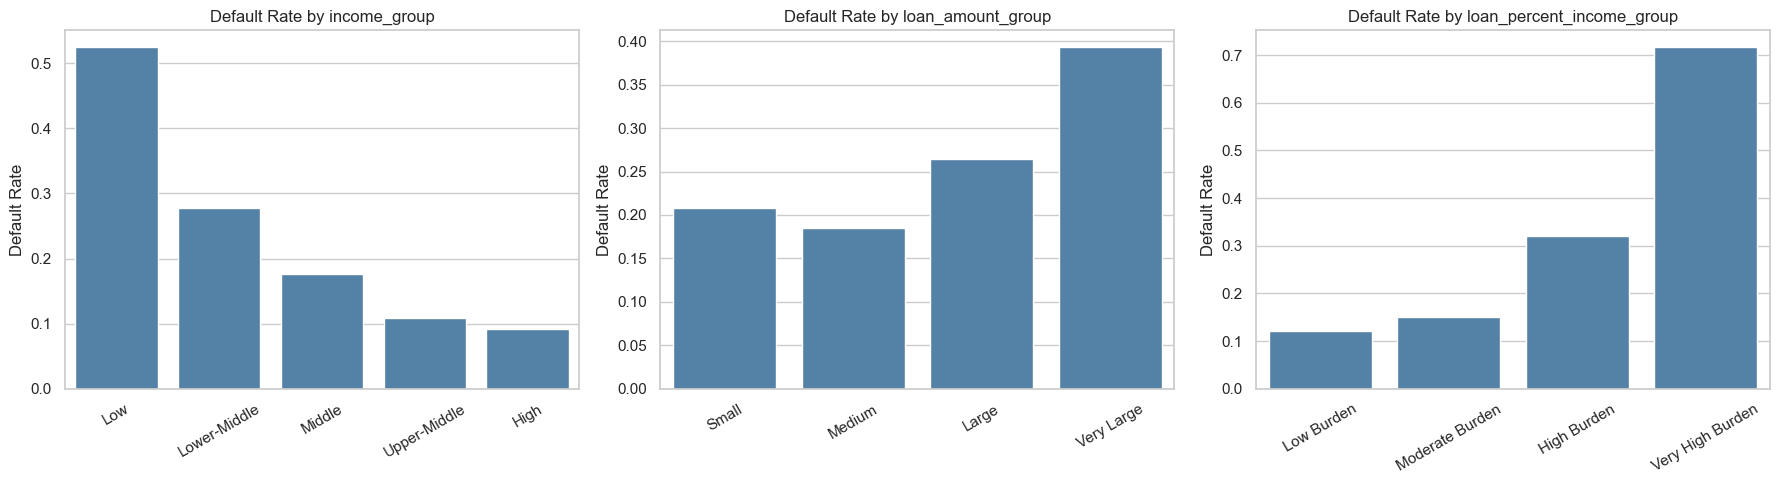

In [30]:
# Store grouped summaries so the plots can be generated consistently.
group_feature_summaries = {
    "income_group": income_group_summary,
    "loan_amount_group": loan_amount_group_summary,
    "loan_percent_income_group": loan_percent_income_group_summary,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, group_name in zip(axes, group_feature_summaries.keys()):
    summary = group_feature_summaries[group_name]
    sns.barplot(data=summary, x=group_name, y="default_rate", color="steelblue", ax=ax)
    ax.set_title(f"Default Rate by {group_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
### 2.3 Credit Grade and Interest Rate Analysis

The main classification model uses an issued-loan framing, so `loan_grade` and `loan_int_rate` are included because those values are known after underwriting. This section checks how default rate and interest rate change across grades.


In [31]:
# Summarize default behavior and interest rate patterns by loan grade.
grade_summary = (
    df_model.groupby("loan_grade")
    .agg(
        loan_count=("loan_status", "size"),
        default_rate=("loan_status", "mean"),
        avg_interest_rate=("loan_int_rate", "mean"),
        avg_loan_percent_income=("loan_percent_income", "mean"),
    )
    .reset_index()
)
grade_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_interest_rate": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})

,loan_grade,loan_count,default_rate,avg_interest_rate,avg_loan_percent_income
0,A,9818,10.46%,7.66,15.75%
1,B,9442,16.92%,11.00,17.98%
2,C,5897,21.64%,13.23,17.46%
3,D,3285,59.91%,14.98,19.60%
4,E,857,65.23%,16.44,21.23%
5,F,209,71.77%,17.76,22.62%
6,G,59,98.31%,19.38,24.95%


The grade and interest-rate summary shows how lender-assigned grades relate to default rates and pricing. This supports including grade and rate in the issued-loan modeling view.


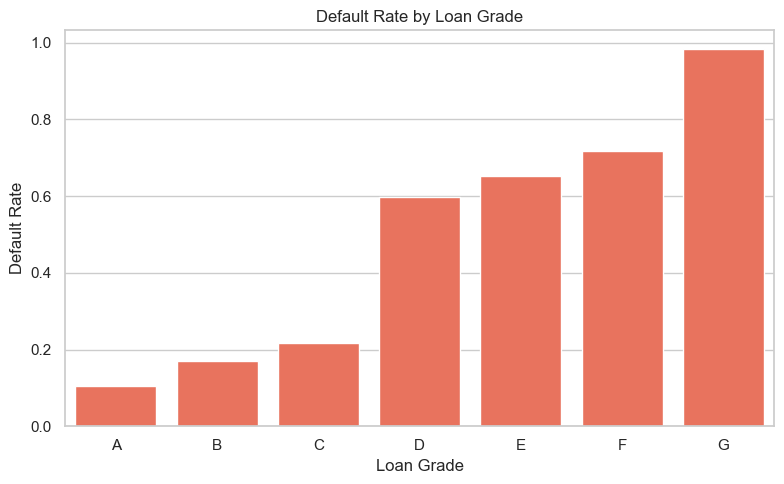

In [32]:
# Plot a focused relationship so grade-level risk is easier to read.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=grade_summary, x="loan_grade", y="default_rate", color="tomato", ax=ax)
ax.set_title("Default Rate by Loan Grade")
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate")
plt.tight_layout()
plt.show()

In [33]:
def summarize_default_probability(data, group_cols):
    # Empirical conditional probabilities
    summary = (
        data.groupby(group_cols, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_probability=("loan_status", "mean"),
        )
        .reset_index()
        .sort_values("default_probability", ascending=False)
    )
    return summary


bn_probability_by_burden = summarize_default_probability(
    df_model, ["loan_percent_income_group", "cb_person_default_on_file"]
)

# Display conditional default probabilities by loan burden and prior default flag.
bn_probability_by_burden.style.format({"default_probability": "{:.2%}"})

,loan_percent_income_group,cb_person_default_on_file,loan_count,default_probability
7,Very High Burden,Y,403,79.16%
6,Very High Burden,N,1672,69.80%
5,High Burden,Y,1494,48.06%
3,Moderate Burden,Y,1844,31.29%
4,High Burden,N,5967,28.00%
1,Low Burden,Y,1461,26.63%
2,Moderate Burden,N,9207,11.83%
0,Low Burden,N,7519,9.39%


---
### 2.4 Save the Phase 2 Modeling Dataset

The feature-engineered dataset is saved as the Phase 2 modeling dataset. This file is used by the statistics and model-building notebook from Chapter 3 onward.


In [34]:
# Create the Phase 2 processed-data folder if it does not already exist.
Path(PHASE2_DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

# Save the feature-engineered modeling dataset created through Chapter 2.
df_model.to_csv(PHASE2_DATA_PATH, index=False)

# Show a short confirmation so the saved dataset is easy to verify.
phase2_save_summary = pd.DataFrame([{
    "saved_path": PHASE2_DATA_PATH,
    "rows": df_model.shape[0],
    "columns": df_model.shape[1],
}])
phase2_save_summary

,saved_path,rows,columns
0,../data/processed/phase2/credit_risk_cleaned.csv,29567,23
